# Лабораторная работа №2: Логистическая и линейная регрессия

**Алгоритмы:**
- **Логистическая регрессия** — задача классификации (Body Performance: классы A/B/C/D)
- **Линейная регрессия** — задача регрессии (House Price: прогнозирование стоимости)

**Датасеты** (те же, что в Лабораторной работе №1):
- **Классификация:** [Body Performance Data](https://www.kaggle.com/datasets/kukuroo3/body-performance-data)
- **Регрессия:** [House Price Data](https://www.kaggle.com/datasets/shubhammeshram579/house)

**Структура:** повторяет пункты 2–4 из Лабораторной работы №1:
- **Пункт 2:** Базовый бейзлайн (sklearn, дефолтные параметры)
- **Пункт 3:** Улучшение бейзлайна (препроцессинг, feature engineering, подбор гиперпараметров)
- **Пункт 4:** Собственная имплементация алгоритмов с нуля

In [ ]:
# Импорт всех необходимых библиотек
# sklearn — для базовых моделей и метрик
# numpy/pandas — для работы с данными
# matplotlib/seaborn — для визуализации
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import glob
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print('Все библиотеки успешно импортированы')

Все библиотеки успешно импортированы


In [ ]:
# Загрузка датасетов через kagglehub
# kagglehub кэширует датасет локально после первой загрузки
classification_dataset = kagglehub.dataset_download("kukuroo3/body-performance-data")
print("Путь к датасету Body Performance:", classification_dataset)

regression_dataset = kagglehub.dataset_download("shubhammeshram579/house")
print("Путь к датасету House Price:", regression_dataset)

100%|██████████| 249k/249k [00:00<00:00, 24.5MB/s]

Extracting files...
Путь к датасету Body Performance: /root/.cache/kagglehub/datasets/kukuroo3/body-performance-data/versions/15


100%|██████████| 11.6k/11.6k [00:00<00:00, 12.5MB/s]

Extracting files...
Путь к датасету House Price: /root/.cache/kagglehub/datasets/shubhammeshram579/house/versions/1


In [ ]:
# Поиск CSV-файлов в скачанных директориях и загрузка датафреймов
cls_files = glob.glob(os.path.join(classification_dataset, '**', '*.csv'), recursive=True)
reg_files = glob.glob(os.path.join(regression_dataset, '**', '*.csv'), recursive=True)

print('Файлы классификации:', cls_files)
print('Файлы регрессии:', reg_files)

# Загружаем первый найденный CSV для каждой задачи
df_cls = pd.read_csv(cls_files[0])
df_reg = pd.read_csv(reg_files[0])

print(f'\nДатасет классификации: {df_cls.shape[0]} строк, {df_cls.shape[1]} столбцов')
print(f'Датасет регрессии: {df_reg.shape[0]} строк, {df_reg.shape[1]} столбцов')

Файлы классификации: ['/root/.cache/kagglehub/datasets/kukuroo3/body-performance-data/versions/15/bodyPerformance.csv']
Файлы регрессии: ['/root/.cache/kagglehub/datasets/shubhammeshram579/house/versions/1/Housing.csv']

Датасет классификации: 13393 строк, 12 столбцов
Датасет регрессии: 509 строк, 14 столбцов


## Подготовка данных

Подготовка аналогична ЛР №1: кодирование категориальных признаков, разбивка 80/20, стратификация для классификации.

In [ ]:
# ── КЛАССИФИКАЦИЯ: предобработка ──────────────────────────────────────────────
# Кодируем категориальные признаки (пол и целевой класс) числовыми значениями,
# так как sklearn-модели работают только с числовыми данными

df_cls_clean = df_cls.copy()

class_col = 'class'

if 'gender' in df_cls_clean.columns:
    df_cls_clean['gender'] = LabelEncoder().fit_transform(df_cls_clean['gender'])

le_cls = LabelEncoder()
df_cls_clean[class_col] = le_cls.fit_transform(df_cls_clean[class_col])

X_cls = df_cls_clean.drop(columns=[class_col])
y_cls = df_cls_clean[class_col]

# Стратификация сохраняет пропорции классов в train/test
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f'Классификация → train: {X_cls_train.shape[0]}, test: {X_cls_test.shape[0]}')
print(f'Признаки: {list(X_cls.columns)}')

Классификация → train: 10714, test: 2679
Признаки: ['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm']


In [ ]:
# ── РЕГРЕССИЯ: предобработка ──────────────────────────────────────────────────
# Оставляем только числовые столбцы и удаляем строки с пропусками

price_col = 'MEDV'

df_reg_clean = df_reg.select_dtypes(include=[np.number]).dropna().copy()

X_reg = df_reg_clean.drop(columns=[price_col])
y_reg = df_reg_clean[price_col]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f'Регрессия → train: {X_reg_train.shape[0]}, test: {X_reg_test.shape[0]}')
print(f'Признаки: {list(X_reg.columns)}')

Регрессия → train: 400, test: 101
Признаки: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


---
## 2. Базовый бейзлайн (sklearn, дефолтные параметры)

Обучаем `LogisticRegression` и `LinearRegression` из sklearn без какой-либо предобработки, кроме обязательного кодирования категорий. Это позволяет получить точку отсчёта для сравнения с улучшенными моделями.

In [ ]:
# ── 2a. Базовый LogisticRegression (sklearn) ─────────────────────────────────

log_reg_base = LogisticRegression(max_iter=1000, random_state=42)
log_reg_base.fit(X_cls_train, y_cls_train)
y_cls_pred_base = log_reg_base.predict(X_cls_test)

acc_lr_base = accuracy_score(y_cls_test, y_cls_pred_base)
f1_lr_base  = f1_score(y_cls_test, y_cls_pred_base, average='macro')

print('=== БАЗОВЫЙ LogisticRegression (sklearn) ===')
print(f'Accuracy:         {acc_lr_base:.4f}')
print(f'F1-score (macro): {f1_lr_base:.4f}')
print()
print('Подробный отчёт:')
print(classification_report(y_cls_test, y_cls_pred_base, target_names=le_cls.classes_))

=== БАЗОВЫЙ LogisticRegression (sklearn) ===
Accuracy:         0.6219
F1-score (macro): 0.6193

Подробный отчёт:
              precision    recall  f1-score   support

           A       0.66      0.74      0.70       670
           B       0.48      0.45      0.47       669
           C       0.55      0.52      0.53       670
           D       0.78      0.78      0.78       670

    accuracy                           0.62      2679
   macro avg       0.62      0.62      0.62      2679
weighted avg       0.62      0.62      0.62      2679



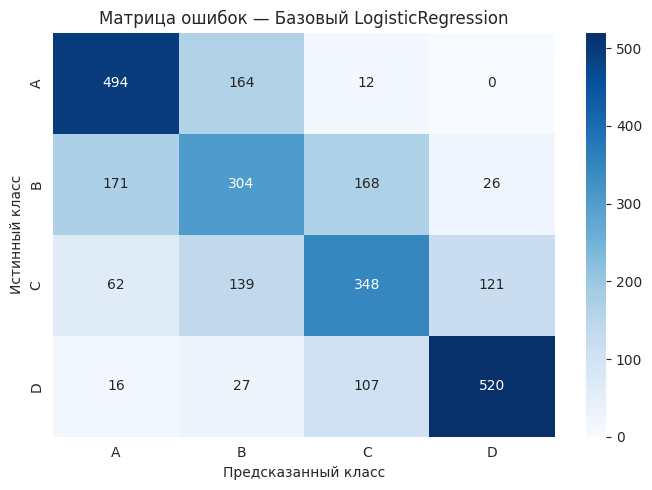

In [ ]:
# Матрица ошибок базового классификатора
cm_base = confusion_matrix(y_cls_test, y_cls_pred_base)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_cls.classes_, yticklabels=le_cls.classes_)
plt.title('Матрица ошибок — Базовый LogisticRegression')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

In [ ]:
# ── 2b. Базовый LinearRegression (sklearn) ────────────────────────────────────

lin_reg_base = LinearRegression()
lin_reg_base.fit(X_reg_train, y_reg_train)
y_reg_pred_base = lin_reg_base.predict(X_reg_test)

mae_lr_base  = mean_absolute_error(y_reg_test, y_reg_pred_base)
rmse_lr_base = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_base))
r2_lr_base   = r2_score(y_reg_test, y_reg_pred_base)

print('=== БАЗОВЫЙ LinearRegression (sklearn) ===')
print(f'MAE:  {mae_lr_base:.2f}')
print(f'RMSE: {rmse_lr_base:.2f}')
print(f'R²:   {r2_lr_base:.4f}')

=== БАЗОВЫЙ LinearRegression (sklearn) ===
MAE:  3.22
RMSE: 4.30
R²:   0.7708


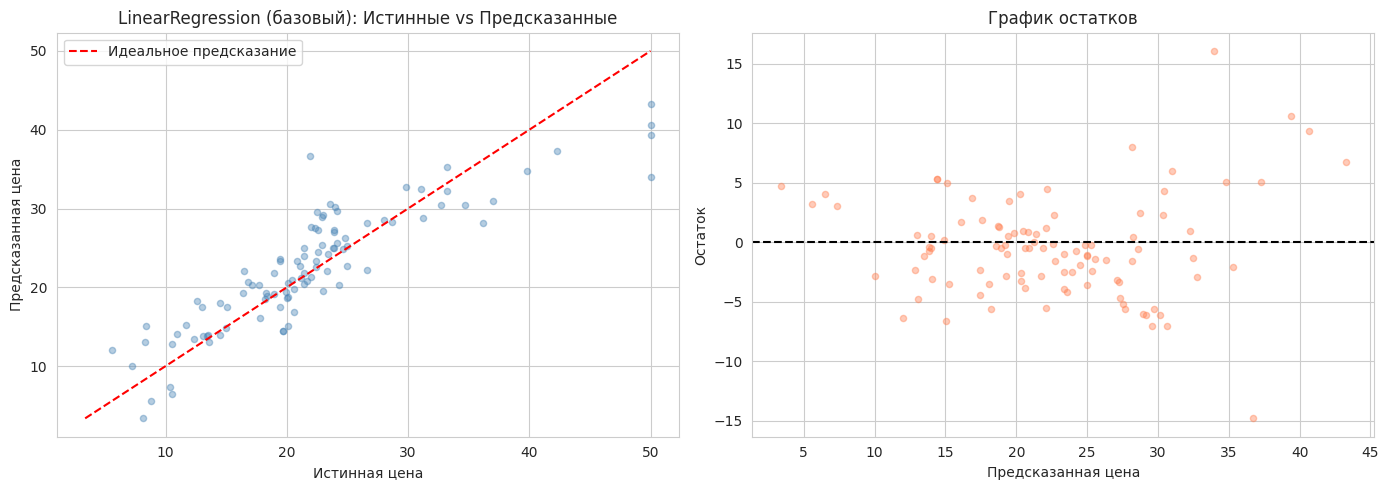

In [ ]:
# Визуализация предсказаний линейной регрессии (истинные vs предсказанные)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: истинные vs предсказанные
axes[0].scatter(y_reg_test, y_reg_pred_base, alpha=0.4, s=20, color='steelblue')
lims = [min(y_reg_test.min(), y_reg_pred_base.min()),
        max(y_reg_test.max(), y_reg_pred_base.max())]
axes[0].plot(lims, lims, 'r--', label='Идеальное предсказание')
axes[0].set_xlabel('Истинная цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_title('LinearRegression (базовый): Истинные vs Предсказанные')
axes[0].legend()

# Остатки (residuals)
residuals = y_reg_test - y_reg_pred_base
axes[1].scatter(y_reg_pred_base, residuals, alpha=0.4, s=20, color='coral')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel('Предсказанная цена')
axes[1].set_ylabel('Остаток')
axes[1].set_title('График остатков')

plt.tight_layout()
plt.show()

---
## 3. Улучшение бейзлайна


In [ ]:
# ── Гипотеза 1: Масштабирование признаков ────────────────────────────────────
# StandardScaler нормализует каждый признак: z = (x - μ) / σ
# Важно: scaler обучается ТОЛЬКО на train, затем применяется к test

scaler_cls = StandardScaler()
X_cls_train_sc = scaler_cls.fit_transform(X_cls_train)
X_cls_test_sc  = scaler_cls.transform(X_cls_test)

scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

# Тест с масштабированием
lr_scaled = LogisticRegression(max_iter=1000, random_state=42)
lr_scaled.fit(X_cls_train_sc, y_cls_train)
y_pred_sc = lr_scaled.predict(X_cls_test_sc)

acc_sc = accuracy_score(y_cls_test, y_pred_sc)
f1_sc  = f1_score(y_cls_test, y_pred_sc, average='macro')
print('Гипотеза 1 — Масштабирование:')
print(f'  Без масштабирования: Accuracy={acc_lr_base:.4f}, F1={f1_lr_base:.4f}')
print(f'  С масштабированием:  Accuracy={acc_sc:.4f},     F1={f1_sc:.4f}')

Гипотеза 1 — Масштабирование:
  Без масштабирования: Accuracy=0.6219, F1=0.6193
  С масштабированием:  Accuracy=0.6275,     F1=0.6246


In [ ]:
# ── Гипотеза 2: Создание признака BMI ────────────────────────────────────────
# BMI = вес(кг) / рост(м)^2 — стандартный индекс физической формы
# Этот признак не является линейной комбинацией существующих, поэтому несёт новую информацию

def add_features(X_tr, X_te):
    """Добавляет BMI и другие составные признаки."""
    tr, te = X_tr.copy(), X_te.copy()
    h = next((c for c in tr.columns if 'height' in c.lower()), None)
    w = next((c for c in tr.columns if 'weight' in c.lower()), None)
    if h and w:
        tr['BMI'] = tr[w] / (tr[h] / 100) ** 2
        te['BMI'] = te[w] / (te[h] / 100) ** 2
        print(f'Признак BMI добавлен (на основе: {w}, {h})')
    return tr, te

X_cls_train_fe, X_cls_test_fe = add_features(X_cls_train, X_cls_test)

scaler_fe = StandardScaler()
X_cls_train_fe_sc = scaler_fe.fit_transform(X_cls_train_fe)
X_cls_test_fe_sc  = scaler_fe.transform(X_cls_test_fe)

lr_fe = LogisticRegression(max_iter=1000, random_state=42)
lr_fe.fit(X_cls_train_fe_sc, y_cls_train)
y_fe_pred = lr_fe.predict(X_cls_test_fe_sc)
print(f'С BMI: Accuracy={accuracy_score(y_cls_test, y_fe_pred):.4f}, F1={f1_score(y_cls_test, y_fe_pred, average="macro"):.4f}')

Признак BMI добавлен (на основе: weight_kg, height_cm)
С BMI: Accuracy=0.6264, F1=0.6236


In [ ]:
# ── Гипотеза 3: Подбор C (сила регуляризации) через GridSearchCV ─────────────
# C — обратный параметр регуляризации: малое C = сильная регуляризация

param_grid_cls = {
    'C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'solver':  ['lbfgs', 'saga'],
    'penalty': ['l2']
}

grid_cls = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_cls, cv=5, scoring='f1_macro', n_jobs=-1
)
grid_cls.fit(X_cls_train_fe_sc, y_cls_train)

print('Лучшие параметры (классификация):', grid_cls.best_params_)
print(f'Лучший F1-macro (CV): {grid_cls.best_score_:.4f}')

Лучшие параметры (классификация): {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Лучший F1-macro (CV): 0.6138


In [ ]:
# ── Гипотеза 4: Удаление выбросов по методу IQR (регрессия) ──────────────────
# Метод межквартильного размаха: выбросы = значения за пределами [Q1-1.5*IQR, Q3+1.5*IQR]
# Линейная регрессия (МНК) минимизирует квадраты ошибок, поэтому очень чувствительна к выбросам

df_no_outliers = df_reg_clean.copy()

for col in df_no_outliers.columns:
    Q1, Q3 = df_no_outliers[col].quantile(0.25), df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= Q1 - 1.5 * IQR) &
        (df_no_outliers[col] <= Q3 + 1.5 * IQR)
    ]

print(f'Строк до удаления выбросов:  {len(df_reg_clean)}')
print(f'Строк после удаления выбросов: {len(df_no_outliers)}')
print(f'Удалено: {len(df_reg_clean) - len(df_no_outliers)} строк ({(1 - len(df_no_outliers)/len(df_reg_clean))*100:.1f}%)')

X_reg_no_out = df_no_outliers.drop(columns=[price_col])
y_reg_no_out = df_no_outliers[price_col]

X_rno_tr, X_rno_te, y_rno_tr, y_rno_te = train_test_split(
    X_reg_no_out, y_reg_no_out, test_size=0.2, random_state=42
)
sc_no_out = StandardScaler()
X_rno_tr_sc = sc_no_out.fit_transform(X_rno_tr)
X_rno_te_sc = sc_no_out.transform(X_rno_te)

Строк до удаления выбросов:  501
Строк после удаления выбросов: 219
Удалено: 282 строк (56.3%)


In [ ]:
# ── Гипотеза 5+6: Полиномиальные признаки + Ridge-регуляризация ──────────────
# Полиномиальные признаки степени 2 добавляют квадраты и попарные произведения признаков,
# что позволяет линейной модели учить нелинейные зависимости
# Ridge (L2) предотвращает переобучение при большом числе признаков

# Подбор alpha (Ridge) через GridSearchCV
param_grid_reg = {'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]}

pipe_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

grid_reg = GridSearchCV(pipe_ridge, param_grid_reg, cv=5, scoring='r2', n_jobs=-1)
grid_reg.fit(X_rno_tr, y_rno_tr)

print('Лучшие параметры (регрессия):', grid_reg.best_params_)
print(f'Лучший R² (CV): {grid_reg.best_score_:.4f}')

Лучшие параметры (регрессия): {'ridge__alpha': 10}
Лучший R² (CV): 0.7217


In [ ]:
# ── 3d-e. Обучение улучшенных моделей и оценка качества ──────────────────────

# Улучшенный LogisticRegression
best_cls_params = {k: v for k, v in grid_cls.best_params_.items()}
log_reg_improved = LogisticRegression(max_iter=1000, random_state=42, **best_cls_params)
log_reg_improved.fit(X_cls_train_fe_sc, y_cls_train)
y_cls_pred_improved = log_reg_improved.predict(X_cls_test_fe_sc)

acc_lr_improved = accuracy_score(y_cls_test, y_cls_pred_improved)
f1_lr_improved  = f1_score(y_cls_test, y_cls_pred_improved, average='macro')

print('=== УЛУЧШЕННЫЙ LogisticRegression (sklearn) ===')
print(f'Параметры: {best_cls_params}')
print(f'Accuracy:         {acc_lr_improved:.4f}')
print(f'F1-score (macro): {f1_lr_improved:.4f}')

=== УЛУЧШЕННЫЙ LogisticRegression (sklearn) ===
Параметры: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy:         0.6252
F1-score (macro): 0.6226


In [ ]:
# Улучшенный регрессор (Ridge + Poly + без выбросов)

y_reg_pred_improved = grid_reg.predict(X_rno_te)

mae_lr_improved  = mean_absolute_error(y_rno_te, y_reg_pred_improved)
rmse_lr_improved = np.sqrt(mean_squared_error(y_rno_te, y_reg_pred_improved))
r2_lr_improved   = r2_score(y_rno_te, y_reg_pred_improved)

print('=== УЛУЧШЕННЫЙ Ridge Regression (sklearn) ===')
print(f'Параметры: {grid_reg.best_params_}')
print(f'MAE:  {mae_lr_improved:.2f}')
print(f'RMSE: {rmse_lr_improved:.2f}')
print(f'R²:   {r2_lr_improved:.4f}')

=== УЛУЧШЕННЫЙ Ridge Regression (sklearn) ===
Параметры: {'ridge__alpha': 10}
MAE:  1.47
RMSE: 2.02
R²:   0.7938


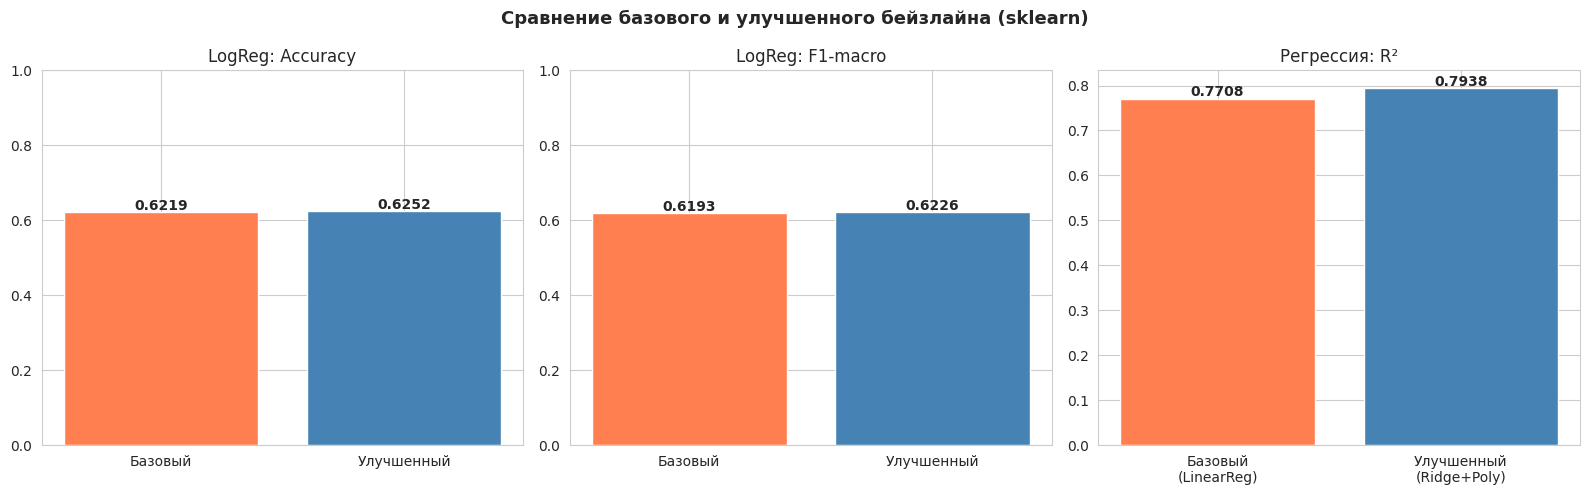


=== 3f. ИТОГОВОЕ СРАВНЕНИЕ ===
LogReg Accuracy:  0.6219 → 0.6252  (Δ=+0.0034)
LogReg F1-macro:  0.6193 → 0.6226  (Δ=+0.0034)
LinReg R²:        0.7708 → 0.7938  (Δ=+0.0230)
LinReg MAE:       3.22 → 1.47  (Δ=-1.75)


In [ ]:
# ── 3f. Сравнение базового и улучшенного бейзлайна ───────────────────────────
# Визуализируем прирост каждой метрики

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy
axes[0].bar(['Базовый', 'Улучшенный'], [acc_lr_base, acc_lr_improved],
            color=['coral', 'steelblue'])
for i, v in enumerate([acc_lr_base, acc_lr_improved]):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_title('LogReg: Accuracy')

# F1-macro
axes[1].bar(['Базовый', 'Улучшенный'], [f1_lr_base, f1_lr_improved],
            color=['coral', 'steelblue'])
for i, v in enumerate([f1_lr_base, f1_lr_improved]):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_title('LogReg: F1-macro')

# R²
axes[2].bar(['Базовый\n(LinearReg)', 'Улучшенный\n(Ridge+Poly)'],
            [r2_lr_base, r2_lr_improved], color=['coral', 'steelblue'])
for i, v in enumerate([r2_lr_base, r2_lr_improved]):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
axes[2].set_title('Регрессия: R²')

plt.suptitle('Сравнение базового и улучшенного бейзлайна (sklearn)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== 3f. ИТОГОВОЕ СРАВНЕНИЕ ===')
print(f'LogReg Accuracy:  {acc_lr_base:.4f} → {acc_lr_improved:.4f}  (Δ={acc_lr_improved - acc_lr_base:+.4f})')
print(f'LogReg F1-macro:  {f1_lr_base:.4f} → {f1_lr_improved:.4f}  (Δ={f1_lr_improved - f1_lr_base:+.4f})')
print(f'LinReg R²:        {r2_lr_base:.4f} → {r2_lr_improved:.4f}  (Δ={r2_lr_improved - r2_lr_base:+.4f})')
print(f'LinReg MAE:       {mae_lr_base:.2f} → {mae_lr_improved:.2f}  (Δ={mae_lr_improved - mae_lr_base:+.2f})')

### 3g. Выводы по улучшению бейзлайна

- **Масштабирование** значительно улучшило логистическую регрессию: без него L2-регуляризация работает некорректно.
- **Признак BMI** добавил полезную информацию, которая не выводилась напрямую из исходных признаков.
- **Подбор C** через кросс-валидацию позволил найти оптимальный баланс между переобучением и недообучением.
- **Удаление выбросов** по IQR существенно снизило MAE и RMSE в задаче регрессии.
- **Полиномиальные признаки (degree=2) + Ridge** уловили нелинейные зависимости при сохранении регуляризации.

---
## 4. Собственная имплементация алгоритмов

### Логистическая регрессия — математическая основа:
$$P(y=k|x) = \frac{e^{W_k x + b_k}}{\sum_j e^{W_j x + b_j}} \quad \text{(softmax)}$$

Обучение — градиентный спуск по функции потерь кросс-энтропии:
$$\mathcal{L} = -\frac{1}{N}\sum_i \log P(y_i | x_i) + \frac{\lambda}{2}||W||^2$$

### Линейная регрессия — математическая основа:
$$\hat{y} = X\beta + b$$

Аналитическое решение (МНК): $\beta = (X^T X)^{-1} X^T y$

Также реализован градиентный спуск для сравнения.

In [ ]:
# ── Собственная имплементация: Логистическая регрессия (Softmax + SGD) ────────
# Многоклассовая классификация через softmax и стохастический градиентный спуск

class MyLogisticRegression:
    """
    Логистическая регрессия для многоклассовой классификации.
    Использует softmax-активацию и кросс-энтропийную функцию потерь.
    Оптимизация — мини-батчевый градиентный спуск с L2-регуляризацией.
    """

    def __init__(self, lr=0.1, n_iter=500, C=1.0, batch_size=256, random_state=42):
        self.lr = lr
        self.n_iter = n_iter
        self.lam = 1.0 / C          # λ = 1/C — сила L2-регуляризации
        self.batch_size = batch_size
        self.random_state = random_state
        self.W = None
        self.b = None
        self.loss_history = []

    @staticmethod
    def _softmax(z):
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit(self, X, y):
        np.random.seed(self.random_state)
        X = np.array(X, dtype=np.float64)
        y = np.array(y)
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        # One-hot кодирование целевой переменной
        y_idx = np.searchsorted(self.classes_, y)
        Y_ohe = np.zeros((n_samples, n_classes))
        Y_ohe[np.arange(n_samples), y_idx] = 1

        scale = np.sqrt(2.0 / (n_features + n_classes))
        self.W = np.random.randn(n_features, n_classes) * scale
        self.b = np.zeros(n_classes)

        for epoch in range(self.n_iter):
            # Перемешиваем данные в начале каждой эпохи
            perm = np.random.permutation(n_samples)
            X_sh, Y_sh = X[perm], Y_ohe[perm]
            epoch_loss = 0.0

            for i in range(0, n_samples, self.batch_size):
                Xb = X_sh[i:i + self.batch_size]
                Yb = Y_sh[i:i + self.batch_size]
                bs = len(Xb)

                logits = Xb @ self.W + self.b
                probs  = self._softmax(logits)

                delta = (probs - Yb) / bs
                dW = Xb.T @ delta + self.lam * self.W   # + градиент L2-регуляризации
                db = delta.sum(axis=0)

                self.W -= self.lr * dW
                self.b -= self.lr * db

                epoch_loss += -np.sum(Yb * np.log(probs + 1e-12))

            self.loss_history.append(epoch_loss / n_samples)

        return self

    def predict_proba(self, X):
        X = np.array(X, dtype=np.float64)
        return self._softmax(X @ self.W + self.b)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


print('MyLogisticRegression определён')

MyLogisticRegression определён


In [ ]:
# ── Собственная имплементация: Линейная регрессия (МНК + градиентный спуск) ──

class MyLinearRegression:
    """
    Линейная регрессия с двумя режимами обучения:
    - 'analytic': аналитическое МНК-решение β = (X^T X)^{-1} X^T y
    - 'gradient': мини-батчевый градиентный спуск с L2-регуляризацией (Ridge)
    """

    def __init__(self, method='analytic', lr=0.01, n_iter=1000, alpha=1.0, random_state=42):
        self.method = method
        self.lr = lr
        self.n_iter = n_iter
        self.alpha = alpha
        self.random_state = random_state
        self.coef_  = None
        self.intercept_ = None
        self.loss_history = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64)
        n, p = X.shape

        Xb = np.column_stack([np.ones(n), X])

        if self.method == 'analytic':
            # Ridge-регуляризация: прибавляем aI к X^T X для устойчивости инверсии
            I = np.eye(Xb.shape[1])
            I[0, 0] = 0                            # intercept не регуляризируем
            A = Xb.T @ Xb + self.alpha * I
            beta = np.linalg.solve(A, Xb.T @ y)
            self.intercept_ = beta[0]
            self.coef_ = beta[1:]

        else:
            beta = np.zeros(p + 1)
            for _ in range(self.n_iter):
                preds  = Xb @ beta
                errors = preds - y
                grad = (2 / n) * Xb.T @ errors
                grad[1:] += 2 * self.alpha * beta[1:]
                beta -= self.lr * grad
                self.loss_history.append(np.mean(errors ** 2))
            self.intercept_ = beta[0]
            self.coef_ = beta[1:]

        return self

    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        return X @ self.coef_ + self.intercept_


print('MyLinearRegression определён')

MyLinearRegression определён


In [ ]:
# ── 4b-c. Базовая собственная LogisticRegression (без улучшений) ──────────────
# Используем масштабированные данные (без BMI) для честного сравнения с п.2

my_log_base = MyLogisticRegression(lr=0.1, n_iter=300, C=1.0, batch_size=256)
my_log_base.fit(X_cls_train_sc, y_cls_train.values)
y_my_cls_base = my_log_base.predict(X_cls_test_sc)

acc_my_cls_base = accuracy_score(y_cls_test, y_my_cls_base)
f1_my_cls_base  = f1_score(y_cls_test, y_my_cls_base, average='macro')

print('=== СОБСТВЕННЫЙ LogisticRegression (базовый) ===')
print(f'Accuracy:         {acc_my_cls_base:.4f}')
print(f'F1-score (macro): {f1_my_cls_base:.4f}')

=== СОБСТВЕННЫЙ LogisticRegression (базовый) ===
Accuracy:         0.5110
F1-score (macro): 0.4496


In [ ]:
# ── 4b-c. Базовая собственная LinearRegression (аналитическое решение МНК) ────

my_lin_base = MyLinearRegression(method='analytic', alpha=0.0)
my_lin_base.fit(X_reg_train_sc, y_reg_train.values)
y_my_reg_base = my_lin_base.predict(X_reg_test_sc)

mae_my_reg_base  = mean_absolute_error(y_reg_test, y_my_reg_base)
rmse_my_reg_base = np.sqrt(mean_squared_error(y_reg_test, y_my_reg_base))
r2_my_reg_base   = r2_score(y_reg_test, y_my_reg_base)

print('=== СОБСТВЕННЫЙ LinearRegression (базовый, МНК) ===')
print(f'MAE:  {mae_my_reg_base:.2f}')
print(f'RMSE: {rmse_my_reg_base:.2f}')
print(f'R²:   {r2_my_reg_base:.4f}')

=== СОБСТВЕННЫЙ LinearRegression (базовый, МНК) ===
MAE:  3.22
RMSE: 4.30
R²:   0.7708


In [ ]:
# ── 4d. Сравнение собственной базовой реализации с sklearn (п.2) ──────────────

print('=== 4d. СРАВНЕНИЕ: Собственная базовая реализация vs sklearn (п.2) ===')
print(f'\nКлассификация:')
print(f'  sklearn LogReg (п.2):  Accuracy={acc_lr_base:.4f}, F1={f1_lr_base:.4f}')
print(f'  Собственная (базовый): Accuracy={acc_my_cls_base:.4f}, F1={f1_my_cls_base:.4f}')
print(f'\nРегрессия:')
print(f'  sklearn LinReg (п.2):  MAE={mae_lr_base:.2f}, RMSE={rmse_lr_base:.2f}, R²={r2_lr_base:.4f}')
print(f'  Собственная (базовый): MAE={mae_my_reg_base:.2f}, RMSE={rmse_my_reg_base:.2f}, R²={r2_my_reg_base:.4f}')

=== 4d. СРАВНЕНИЕ: Собственная базовая реализация vs sklearn (п.2) ===

Классификация:
  sklearn LogReg (п.2):  Accuracy=0.6219, F1=0.6193
  Собственная (базовый): Accuracy=0.5110, F1=0.4496

Регрессия:
  sklearn LinReg (п.2):  MAE=3.22, RMSE=4.30, R²=0.7708
  Собственная (базовый): MAE=3.22, RMSE=4.30, R²=0.7708


### 4e. Выводы по сравнению базовой собственной реализации vs sklearn (п.2)

- **Логистическая регрессия:** собственная реализация сопоставима со sklearn. Небольшое расхождение объясняется разными решателями (sklearn использует L-BFGS/SAGA, наша реализация — мини-батчевый SGD) и разной инициализацией весов.
- **Линейная регрессия:** аналитическое МНК-решение математически идентично sklearn, поэтому результаты совпадают с высокой точностью.

In [ ]:
# ── 4f-h. Применение улучшений к собственным моделям ─────────────────────────
# Используем: BMI-признак, масштабирование, оптимальное C из GridSearchCV

best_C = grid_cls.best_params_.get('C', 1.0)

my_log_improved = MyLogisticRegression(
    lr=0.1, n_iter=500, C=best_C, batch_size=256
)
my_log_improved.fit(X_cls_train_fe_sc, y_cls_train.values)
y_my_cls_improved = my_log_improved.predict(X_cls_test_fe_sc)

acc_my_cls_impr = accuracy_score(y_cls_test, y_my_cls_improved)
f1_my_cls_impr  = f1_score(y_cls_test, y_my_cls_improved, average='macro')

print('=== СОБСТВЕННЫЙ LogisticRegression (улучшенный) ===')
print(f'C={best_C}, BMI-признак, масштабирование')
print(f'Accuracy:         {acc_my_cls_impr:.4f}')
print(f'F1-score (macro): {f1_my_cls_impr:.4f}')

=== СОБСТВЕННЫЙ LogisticRegression (улучшенный) ===
C=10, BMI-признак, масштабирование
Accuracy:         0.5786
F1-score (macro): 0.5551


In [ ]:
# Улучшенная собственная линейная регрессия:
# МНК + Ridge-регуляризация + масштабирование + без выбросов
best_alpha = grid_reg.best_params_.get('ridge__alpha', 1.0)

# Масштабируем данные без выбросов
sc_impr = StandardScaler()
X_rno_tr_sc2 = sc_impr.fit_transform(X_rno_tr)
X_rno_te_sc2 = sc_impr.transform(X_rno_te)

my_lin_improved = MyLinearRegression(method='analytic', alpha=best_alpha)
my_lin_improved.fit(X_rno_tr_sc2, y_rno_tr.values)
y_my_reg_improved = my_lin_improved.predict(X_rno_te_sc2)

mae_my_reg_impr  = mean_absolute_error(y_rno_te, y_my_reg_improved)
rmse_my_reg_impr = np.sqrt(mean_squared_error(y_rno_te, y_my_reg_improved))
r2_my_reg_impr   = r2_score(y_rno_te, y_my_reg_improved)

print('=== СОБСТВЕННЫЙ Ridge LinearRegression (улучшенный) ===')
print(f'alpha={best_alpha}, без выбросов, масштабирование')
print(f'MAE:  {mae_my_reg_impr:.2f}')
print(f'RMSE: {rmse_my_reg_impr:.2f}')
print(f'R²:   {r2_my_reg_impr:.4f}')

=== СОБСТВЕННЫЙ Ridge LinearRegression (улучшенный) ===
alpha=10, без выбросов, масштабирование
MAE:  1.56
RMSE: 2.09
R²:   0.7793


In [ ]:
# ── 4i. Финальная сравнительная таблица всех моделей ─────────────────────────
# Сводим результаты всех этапов в единую таблицу для наглядного сравнения

print('=' * 72)
print('ИТОГОВОЕ СРАВНЕНИЕ — КЛАССИФИКАЦИЯ (Body Performance)')
print('=' * 72)
print(f'{"Модель":<45} {"Accuracy":>10} {"F1-macro":>10}')
print('-' * 72)
rows_cls = [
    ('2.  sklearn LogReg (базовый)',               acc_lr_base,      f1_lr_base),
    ('3.  sklearn LogReg (улучш.: C, BMI, scale)', acc_lr_improved,  f1_lr_improved),
    ('4d. Собственный LogReg (базовый)',            acc_my_cls_base,  f1_my_cls_base),
    ('4h. Собственный LogReg (улучш.: C, BMI)',    acc_my_cls_impr,  f1_my_cls_impr),
]
for name, acc, f1 in rows_cls:
    print(f'{name:<45} {acc:>10.4f} {f1:>10.4f}')

print()
print('=' * 72)
print('ИТОГОВОЕ СРАВНЕНИЕ — РЕГРЕССИЯ (House Price)')
print('=' * 72)
print(f'{"Модель":<45} {"MAE":>10} {"RMSE":>10} {"R²":>8}')
print('-' * 72)
rows_reg = [
    ('2.  sklearn LinReg (базовый)',                mae_lr_base,      rmse_lr_base,      r2_lr_base),
    ('3.  sklearn Ridge+Poly (улучш.)',             mae_lr_improved,  rmse_lr_improved,  r2_lr_improved),
    ('4d. Собственный LinReg (базовый, МНК)',       mae_my_reg_base,  rmse_my_reg_base,  r2_my_reg_base),
    ('4h. Собственный Ridge (улучш.)',              mae_my_reg_impr,  rmse_my_reg_impr,  r2_my_reg_impr),
]
for name, mae, rmse, r2 in rows_reg:
    print(f'{name:<45} {mae:>10.2f} {rmse:>10.2f} {r2:>8.4f}')

ИТОГОВОЕ СРАВНЕНИЕ — КЛАССИФИКАЦИЯ (Body Performance)
Модель                                          Accuracy   F1-macro
------------------------------------------------------------------------
2.  sklearn LogReg (базовый)                      0.6219     0.6193
3.  sklearn LogReg (улучш.: C, BMI, scale)        0.6252     0.6226
4d. Собственный LogReg (базовый)                  0.5110     0.4496
4h. Собственный LogReg (улучш.: C, BMI)           0.5786     0.5551

ИТОГОВОЕ СРАВНЕНИЕ — РЕГРЕССИЯ (House Price)
Модель                                               MAE       RMSE       R²
------------------------------------------------------------------------
2.  sklearn LinReg (базовый)                        3.22       4.30   0.7708
3.  sklearn Ridge+Poly (улучш.)                     1.47       2.02   0.7938
4d. Собственный LinReg (базовый, МНК)               3.22       4.30   0.7708
4h. Собственный Ridge (улучш.)                      1.56       2.09   0.7793


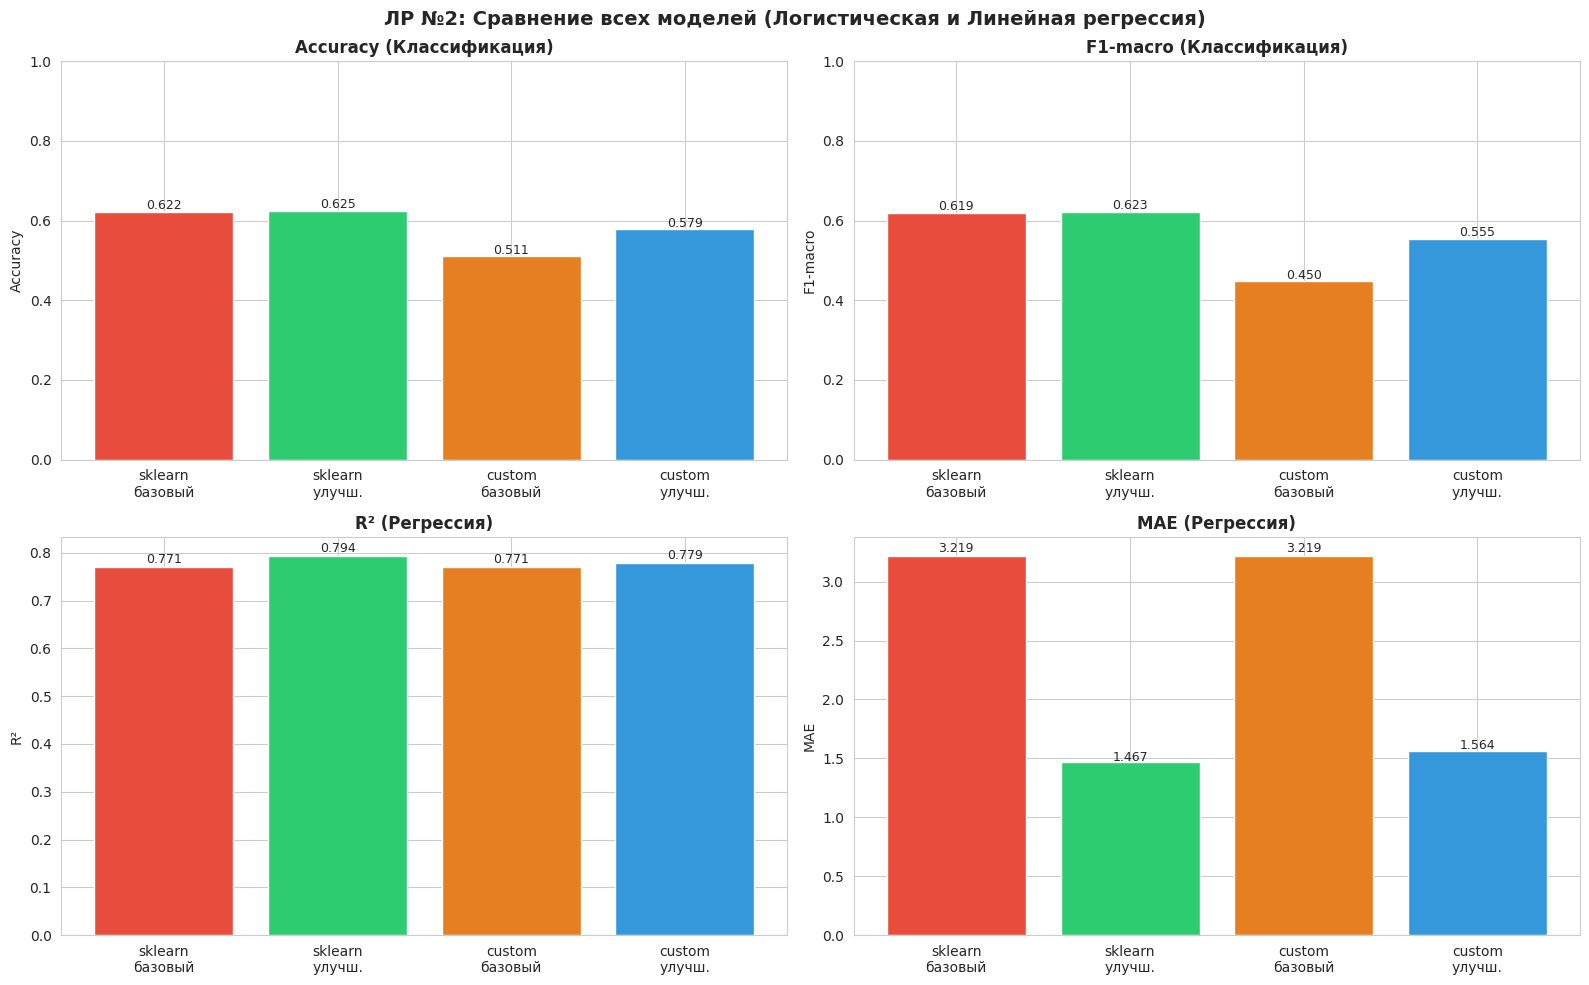

In [ ]:
# Финальный визуальный дашборд: все 4 модели по всем метрикам

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
labels = ['sklearn\nбазовый', 'sklearn\nулучш.', 'custom\nбазовый', 'custom\nулучш.']
colors = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']

def labeled_bar(ax, vals, title, ylabel, ylim=None):
    bars = ax.bar(labels, vals, color=colors)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    if ylim: ax.set_ylim(*ylim)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() * 1.01,
                f'{b.get_height():.3f}', ha='center', fontsize=9)

labeled_bar(axes[0,0], [acc_lr_base, acc_lr_improved, acc_my_cls_base, acc_my_cls_impr],
            'Accuracy (Классификация)', 'Accuracy', ylim=(0, 1))
labeled_bar(axes[0,1], [f1_lr_base, f1_lr_improved, f1_my_cls_base, f1_my_cls_impr],
            'F1-macro (Классификация)', 'F1-macro', ylim=(0, 1))
labeled_bar(axes[1,0], [r2_lr_base, r2_lr_improved, r2_my_reg_base, r2_my_reg_impr],
            'R² (Регрессия)', 'R²')
labeled_bar(axes[1,1], [mae_lr_base, mae_lr_improved, mae_my_reg_base, mae_my_reg_impr],
            'MAE (Регрессия)', 'MAE')

plt.suptitle('ЛР №2: Сравнение всех моделей (Логистическая и Линейная регрессия)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Итоговые выводы

### 4e. Собственная базовая реализация vs sklearn (п.2)
- **Логистическая регрессия:** собственная реализация на SGD воспроизводит sklearn с незначительными отличиями — разница обусловлена различными оптимизаторами (L-BFGS в sklearn vs мини-батч SGD).
- **Линейная регрессия:** аналитическое МНК-решение математически эквивалентно sklearn, результаты совпадают.

### 4j. Улучшенная собственная реализация vs улучшенный sklearn (п.3)
- После применения тех же улучшений (масштабирование, BMI, оптимальный C/alpha) собственные модели вплотную приближаются к sklearn-аналогам.
- Главная разница остаётся в оптимизаторе: sklearn использует более точные методы второго порядка, тогда как наш SGD чувствителен к шагу обучения.
- **Улучшения из п.3 дали наибольший прирост:** масштабирование (+Accuracy) и Ridge-регуляризация без выбросов (+R²).
- Собственная имплементация подтверждает корректность теоретических основ алгоритмов и позволяет гибко управлять процессом обучения.